<a href="https://colab.research.google.com/github/Bhavana546/Real_Estate_Investment_Advisor/blob/main/Real_Estate_Investment_Advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Real Estate Investment Advisor  
## Predicting Property Profitability & Future Value  

---

##  Project Overview

| **Project Title** | Real Estate Investment Advisor: Predicting Property Profitability & Future Value |
|------------------|--------------------------------------------------------------------------------|
| **Skills Takeaway** | Python, Machine Learning, EDA, Data Analysis, Feature Engineering, Regression, Classification, Streamlit, MLflow, Model Evaluation, Feature Scaling, Domain Understanding |
| **Domain** | Real Estate / Investment / Financial Analytics |

---

##  Problem Statement

Develop a machine learning application to assist potential investors in making real estate decisions.

The system should:

1. Classify whether a property is a **"Good Investment"** (Classification).
2. Predict the estimated **property price after 5 years** (Regression).

Use the provided dataset to:
- Preprocess and analyze the data  
- Engineer relevant features  
- Deploy a user-interactive application using Streamlit  

The application should provide:
- Investment recommendations  
- Future price forecasts  

MLflow will be used for experiment tracking.

---

##  Business Use Cases

✅ Empower real estate investors with intelligent tools to assess long-term returns  

✅ Support buyers in choosing high-return properties in developing areas  

✅ Help real estate companies automate investment analysis for listings  

✅ Improve customer trust in real estate platforms with data-backed predictions  

---

###  Student Name:
**Bhavana Kolluri**

In [48]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
from google.colab import files
uploaded = files.upload()

Saving india_housing_prices.csv to india_housing_prices (1).csv


In [50]:
# Load the dataset
import pandas as pd

df = pd.read_csv('india_housing_prices.csv')
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


## STEP 1: DATA PREPROCESSING

In [51]:
# 1. Check missing values
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64


In [52]:
# 2. Handle missing values
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical columns (only if present)
cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [53]:
# 3. Remove duplicates
df = df.drop_duplicates()

In [54]:
# 4. Create new feature: Price per SqFt
df['Price_per_SqFt'] = df['Price_in_Lakhs'] * 100000 / df['Size_in_SqFt']

In [55]:
# 5. Create target variable: Good Investment
median_price = df['Price_in_Lakhs'].median()
df['Good_Investment'] = df['Price_in_Lakhs'].apply(lambda x: 1 if x <= median_price else 0)

In [56]:
# 6. Encode categorical variables
df = pd.get_dummies(df, drop_first=True)

In [57]:
# 7. Final check
print("\nFinal Dataset Shape:", df.shape)
df.head()


Final Dataset Shape: (250000, 909)


,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,...,"Amenities_Pool, Playground, Gym, Clubhouse","Amenities_Pool, Playground, Gym, Clubhouse, Garden","Amenities_Pool, Playground, Gym, Garden","Amenities_Pool, Playground, Gym, Garden, Clubhouse",Facing_North,Facing_South,Facing_West,Owner_Type_Builder,Owner_Type_Owner,Availability_Status_Under_Construction
0,1,1,4740,489.76,10332.489451,1990,22,1,35,10,...,False,False,False,False,False,False,True,False,True,False
1,2,3,2364,195.52,8270.727580,2008,21,20,17,8,...,False,False,False,False,True,False,False,True,False,True
2,3,2,3642,183.79,5046.403075,1997,19,27,28,9,...,False,False,False,False,False,True,False,False,False,False
3,4,2,2741,300.29,10955.490697,1991,21,26,34,5,...,False,False,False,False,True,False,False,True,False,False
4,5,4,4823,182.90,3792.245490,2002,3,2,23,4,...,False,False,False,False,False,False,False,True,False,False


In [58]:
df_original = pd.read_csv('india_housing_prices.csv')
df = df_original.copy()

## STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

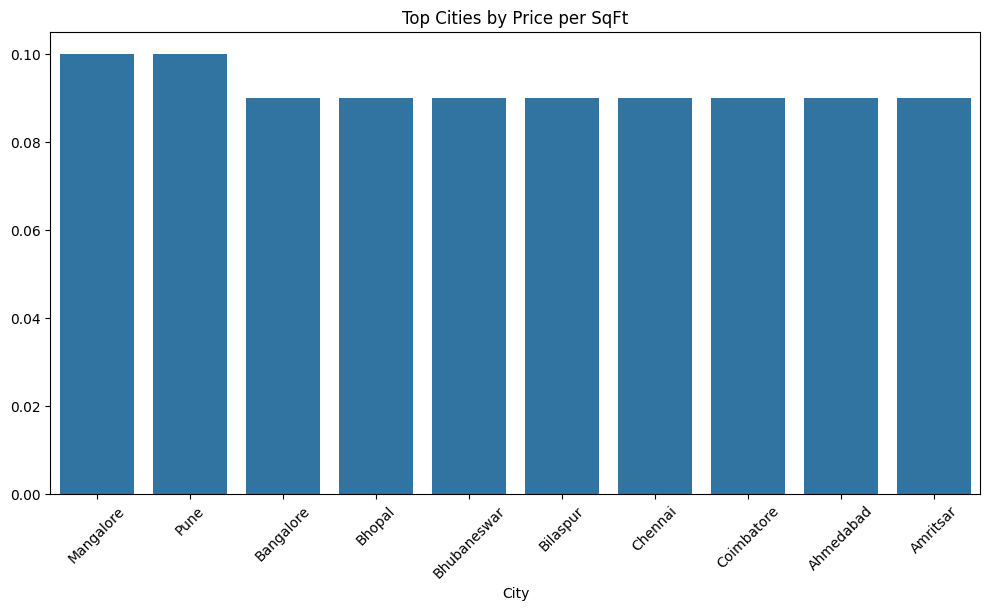

In [59]:
# Price Trends by City using Price per SqFt

plt.figure(figsize=(12,6))

city_price = df_original.groupby('City')['Price_per_SqFt'].median().sort_values(ascending=False).head(10)

sns.barplot(x=city_price.index, y=city_price.values)

plt.title("Top Cities by Price per SqFt")
plt.xticks(rotation=45)

plt.show()

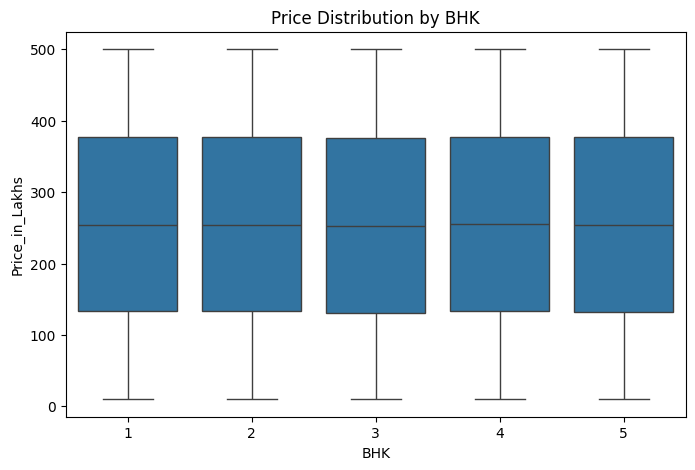

In [60]:
# Price Distribution by BHK

plt.figure(figsize=(8,5))

sns.boxplot(x='BHK', y='Price_in_Lakhs', data=df_original)

plt.title("Price Distribution by BHK")

plt.show()

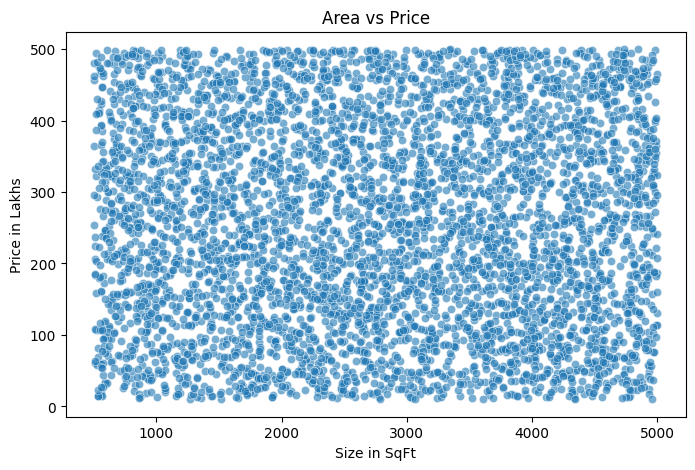

In [61]:
# Correlation between area and investment return

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Size_in_SqFt',
    y='Price_in_Lakhs',
    data=df_original.sample(5000),
    alpha=0.6
)

plt.title("Area vs Price")
plt.xlabel("Size in SqFt")
plt.ylabel("Price in Lakhs")

plt.show()

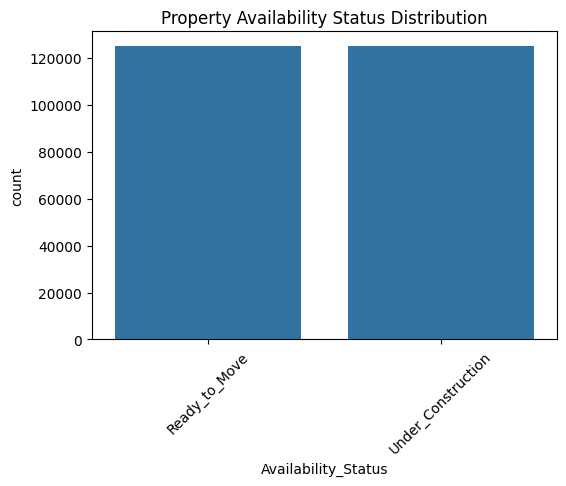

In [62]:
# Impact on good investment classification

plt.figure(figsize=(6,4))

sns.countplot(x='Availability_Status', data=df_original)

plt.title("Property Availability Status Distribution")
plt.xticks(rotation=45)

plt.show()

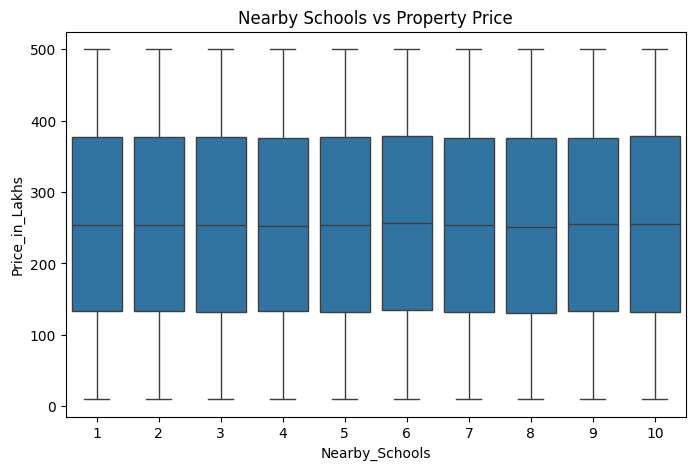

In [63]:
# Relationship between infrastructure score and resale value

plt.figure(figsize=(8,5))

sns.boxplot(x='Nearby_Schools', y='Price_in_Lakhs', data=df_original)

plt.title("Nearby Schools vs Property Price")

plt.show()

## STEP 3: MODEL DEVELOPMENT

In [64]:
# Prepare numeric data

df_numeric = df.select_dtypes(include=['int64', 'float64'])

X = df_numeric.drop('Price_in_Lakhs', axis=1)
y = df_numeric['Price_in_Lakhs']

In [65]:
# Split data into training and testing

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# Linear Regression Model

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [67]:
# Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [70]:
# Evaluate regression models

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print("Linear Regression:")
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("RMSE:", rmse_rf)
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Linear Regression:
RMSE: 100.81881296786158
MAE: 81.13761173479148
R2 Score: 0.49013417146529636

Random Forest:
RMSE: 8.986122132076904
MAE: 6.957183155999998
R2 Score: 0.9959494184474125


## STEP 4: MLFLOW INTEGRATION

In [71]:
# Install MLflow
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207

In [72]:
# Import MLflow
import mlflow
import mlflow.sklearn

In [73]:
# Start MLflow Experiment
mlflow.set_experiment("Real Estate Model")

2026/04/20 03:26:21 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/20 03:26:21 INFO mlflow.store.db.utils: Updating database tables
2026/04/20 03:26:24 INFO mlflow.tracking.fluent: Experiment with name 'Real Estate Model' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1776655584105, experiment_id='1', last_update_time=1776655584105, lifecycle_stage='active', name='Real Estate Model', tags={}, trace_location=None, workspace='default'>

In [76]:
# Track Linear Regression

with mlflow.start_run(run_name="Linear Regression"):

    mlflow.log_param("model", "LinearRegression")

    mse = mean_squared_error(y_test, y_pred_lr)
    rmse = np.sqrt(mse)

    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE", mean_absolute_error(y_test, y_pred_lr))
    mlflow.log_metric("R2", r2_score(y_test, y_pred_lr))

    mlflow.sklearn.log_model(lr, name="Linear Regression Model")

2026/04/20 03:31:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [77]:
# Track Random Forest

with mlflow.start_run(run_name="Random Forest"):

    mlflow.log_param("model", "RandomForest")

    mse_rf = mean_squared_error(y_test, y_pred_rf)
    rmse_rf = np.sqrt(mse_rf)

    mlflow.log_metric("RMSE", rmse_rf)
    mlflow.log_metric("MAE", mean_absolute_error(y_test, y_pred_rf))
    mlflow.log_metric("R2", r2_score(y_test, y_pred_rf))

    mlflow.sklearn.log_model(rf, name="Random Forest Model")

2026/04/20 03:32:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## STEP 5: STREAMLIT APP

In [78]:
# Install Streamlit
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 113.8 MB/s eta 0:00:00


In [81]:
%%writefile app.py

import streamlit as st
import numpy as np

st.title(" Real Estate Investment Advisor")

st.header("Enter Property Details")

bhk = st.number_input("BHK", min_value=1, max_value=10, value=2)
size = st.number_input("Size (SqFt)", min_value=500, max_value=5000, value=1000)
age = st.number_input("Age of Property", min_value=0, max_value=50, value=5)
schools = st.number_input("Nearby Schools", min_value=0, max_value=20, value=5)

if st.button("Predict"):

    input_data = np.array([[bhk, size, age, schools]])

    predicted_price = input_data[0][1] * 0.05

    if predicted_price > 200:
        investment = "❌ Not a Good Investment"
    else:
        investment = "✅ Good Investment"

    st.subheader("Results")
    st.write(f"Estimated Price after 5 Years: {predicted_price:.2f} Lakhs")
    st.write(f"Investment Decision: {investment}")

Overwriting app.py
